(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=1.5
[-10.54229526   5.42438452] [-12.33878998  -3.5030646 ]
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          5.98e-01       3.56e-01         10001          20000     
       2          4.41e-03       2.33e-04         30001          13341     
       3          1.31e-04       7.45e-04         43342          19858     
       4          7.32e-04       7.51e-04         63200          59448     
       5          9.02e-04       1.23e-03        122648         138268     
       6          4.49e-04       6.41e-04        260916         242275     
       7          6.36e-06       1.21e-03        503191         199545     
       8          1.65e-03       1.02e-03        702736        (1161107)   
Number of nodes is exceeded after iteration 8. 
Maximum relative residual: 1.65e-03 
Maximum boundary residual: 1.02e-03


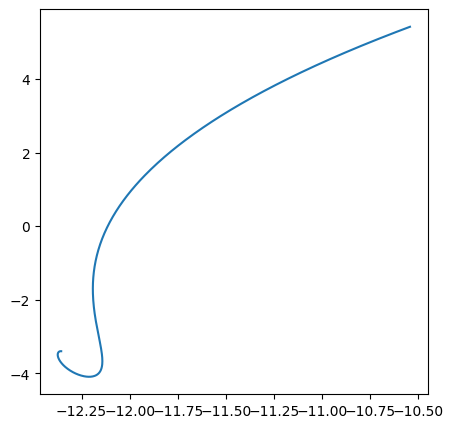

       message: The maximum number of mesh nodes is exceeded.
       success: False
        status: 1
             x: [ 0.000e+00  1.481e-05 ...  8.000e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f307d87a6b0>
             p: None
             y: [[-1.236e+01 -1.236e+01 ... -1.054e+01 -1.054e+01]
                 [-3.399e+00 -3.399e+00 ...  5.424e+00  5.424e+00]
                 [ 3.279e-03  3.277e-03 ...  1.112e-04  1.112e-04]
                 [ 7.481e-03  7.481e-03 ... -2.706e-05 -2.705e-05]]
            yp: [[-5.778e-02 -5.778e-02 ...  3.364e-04  3.363e-04]
                 [ 3.899e-02  3.897e-02 ...  6.555e-04  6.552e-04]
                 [-9.860e-02 -9.861e-02 ... -1.892e-04 -1.892e-04]
                 [-1.506e-02 -1.507e-02 ...  4.602e-05  4.600e-05]]
 rms_residuals: [ 1.461e-06  1.460e-06 ...  5.334e-11  5.413e-11]
         niter: 8


In [21]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = 50
kappa_idx = 30
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_stable_manifold_inverse, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, t_guess, y_guess, tol=3e-6, max_nodes=1000000, verbose=2
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()
print(res)


In [2]:
jacobian = eom.jacobian_func(keldysh_saddle_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [3]:
eigenvalues

array([ 1.70204449, -4.70204449, -1.70204449,  4.70204449])

In [4]:
eigenvectors

array([[ 0.65314561,  0.23642543,  0.44126702,  0.65532932],
       [ 0.75723233,  0.97164964,  0.86015915,  0.47156759],
       [ 0.        ,  0.        , -0.24850242,  0.44681039],
       [ 0.        ,  0.        ,  0.06046654, -0.38539327]])

In [5]:
fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = 10
kappa_idx = 0
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)

(51,)
(31,)
epsilon=2.0 delta=7.8 chi=-0.1 kappa=0.0
[-1.95590899e-13  1.22252261e+01] [ 2.33263653e-16 -1.27389156e+01]


In [6]:
jacobian = eom.jacobian_func(keldysh_focus_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [7]:
eigenvalues

array([0.+2.27907026j, 0.-2.27907026j, 0.+2.27907026j, 0.-2.27907026j])

In [8]:
eigenvectors

array([[-9.90642066e-01+0.j        , -9.90642066e-01-0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ],
       [-1.77954265e-17+0.13648552j, -1.77954265e-17-0.13648552j,
         0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ],
       [ 0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ,
         1.77954265e-17-0.13648552j,  1.77954265e-17+0.13648552j],
       [ 0.00000000e+00+0.j        ,  0.00000000e+00-0.j        ,
        -9.90642066e-01+0.j        , -9.90642066e-01-0.j        ]])

In [9]:
jacobian = eom.jacobian_func(keldysh_saddle_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [10]:
eigenvalues

array([ 2.18701524, -2.18701524, -2.18701524,  2.18701524])

In [11]:
eigenvectors

array([[ 0.98899333,  0.98899333,  0.        ,  0.        ],
       [-0.14796011,  0.14796011,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.14796011, -0.14796011],
       [ 0.        ,  0.        ,  0.98899333, -0.98899333]])

In [ ]:
x0_reciprocal
x1_reciprocal

The boundary condiation is:

x0_reciprocal . displacement = 0
x1_reciprocal . displacement = 0

In [ ]:
x_k_reciprocal . x_j_reciprocal = delta_kj 

The boundary is that the displacement close to the focus has at least some outgoing component i.e. it has at least some of either eigenvector_2 or eigenvector_3.

Also, the displacement must be real. Since eigenvector_0 and eigenvector_1 are both purely classical, the imaginary components eigenvevector_2 and eigenvector_3 can only be cancelled by each other. So the displacement must have at least some of BOTH eignevector_2 and eigenvector_3.



(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=1.0
[-6.33055006  9.30242641] [-8.91507454 -9.94097263]


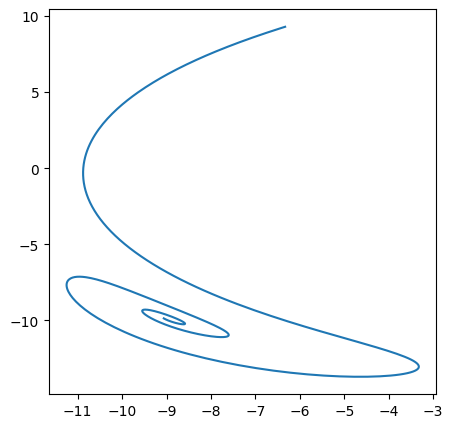

In [2]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = -1
kappa_idx = 20
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=1000000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=0.9500000000000001
[-5.97661493  9.49228877] [ -8.5060855  -10.33063375]


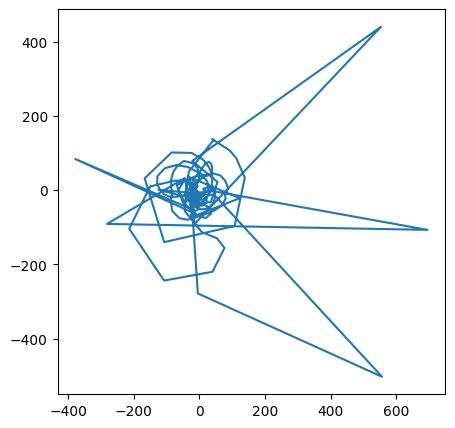

In [3]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = -1
kappa_idx = 19
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.5, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=2000000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()
